# Study 1
 - 14548R
 - neutral
 - 50 N
 - 32 total runs

## Parameters
 - Elastico Neo-Hookean C10 and D1
 - Vero E & $\nu$
 - Friction


#### Friction: $\mu$ = [0.0, 1.0]
 - Dry elastico could have friction ~ 1.0
 - So elastico-tekscan probably slightly less
 - Have results for near frictionless case of $\mu$ = 0.01

#### Vero properties: E = [1500, 3000] ; $\nu$ = [0.25, 0.45]
 - Have compression experimental data, which suggests values as low as E = 15 but data sheet suggests values as high as E = 3000

# Study 2
 - Try Ogden fit that fits compression data well but result in different tension behaviour 
    - Aim for around 400% extension at about 3-5MPa , to match data sheet
---
 - Problem with with this is it doesn't match either of the compression curves used in the neo_hookean fit so can't tell if differences are due to tension or compression behaviour (almost certainly the compression behaviour given 90% for tensile strain = 0.5)

# Study 3
- Same as study 2 but with D1 = 1.0 (forgot in study 2)

# Study 4
 - Same as study 2/3 but with 0.25 ogden scale
 - Provides comparison for ogden with near identical compressive behaviour

# Study 5
- Replaces all previous studies
 - a/b: constant tensile behaviour, 2 compression curves
 - c/d: constant compressive behaviour, 2 tensile curves
 - also updated bone.E to [1400, 3000]
---
- used ogden fits with realtively low variation to keep within what is reasonable for elastico based on my experimental data 
and that papers tension experimental data 

# Study 1

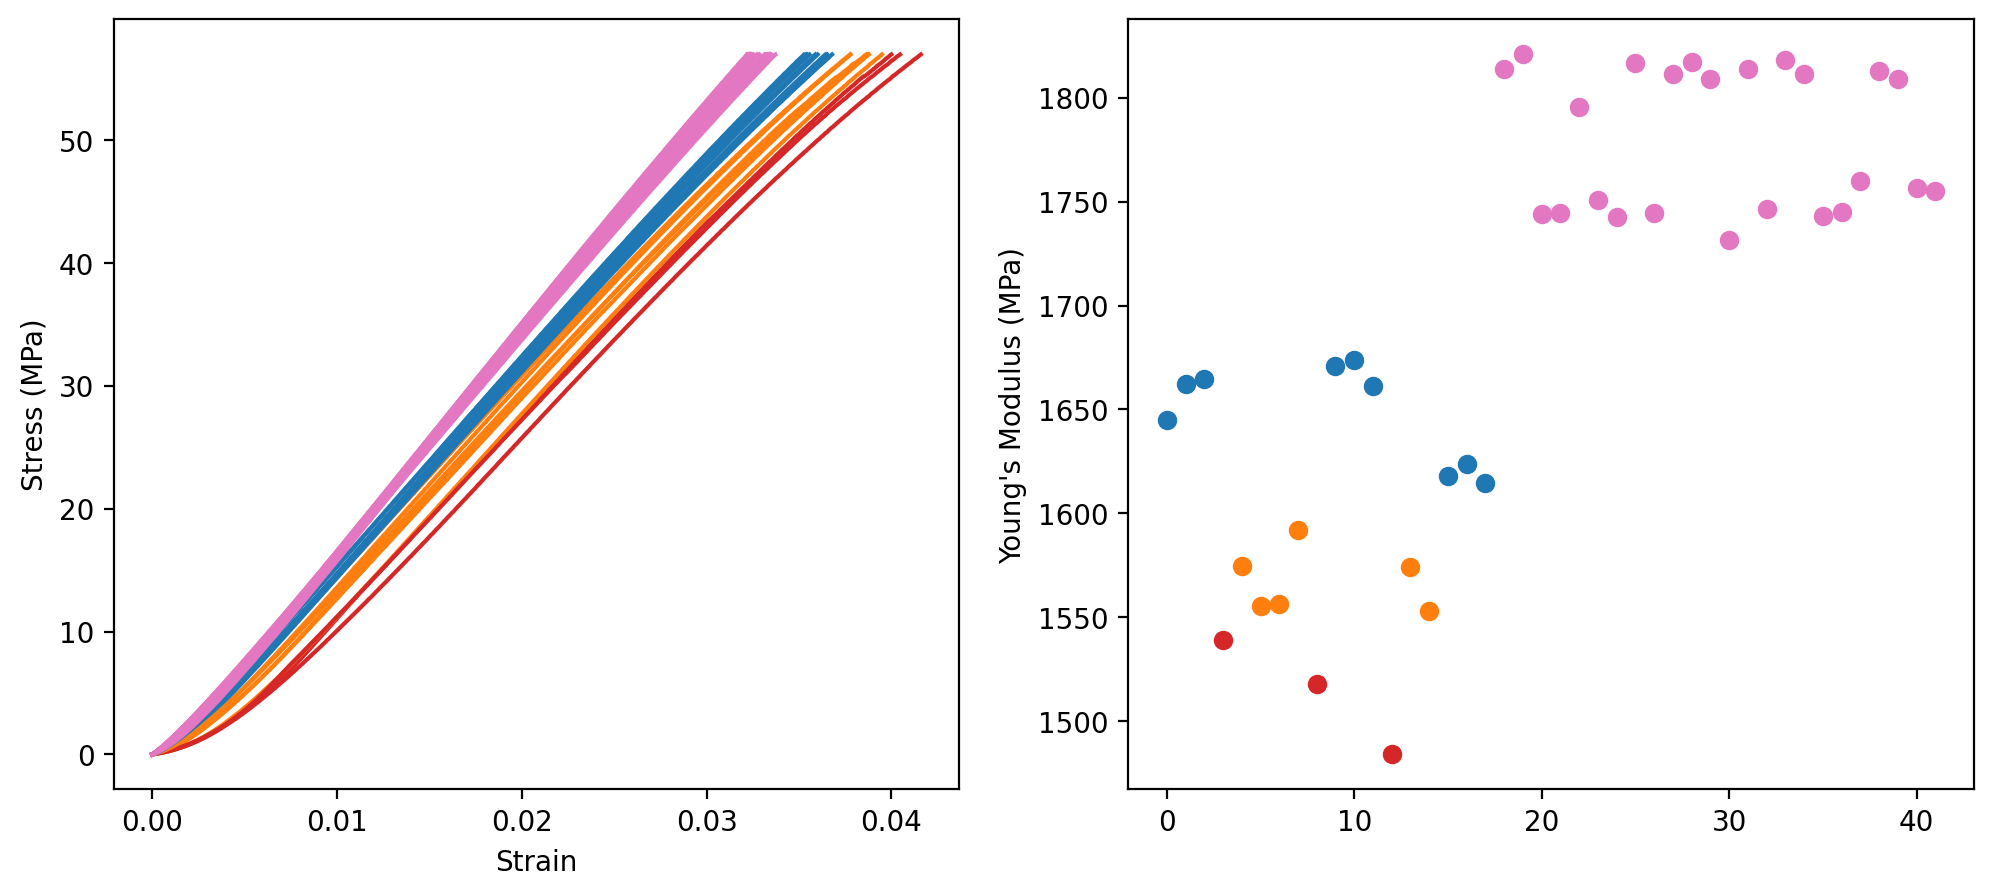

In [296]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from phd_helpers.experiments import get_instron_data

def linear_fit(x, y):
    result = linregress(x, y)
    return result.slope, result.intercept


# Range of Young's modulus values
Es = []
count = 0
# Original test #

orig_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/VeroCylinders/20251217')
glob = '**/*[HV]?_[123].csv'

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=200)


L = 20 # mm length
A = np.pi*(5**2) # mm^2 area

orient_idx = -8
c_orig = {'V':'C0', 'H': 'C1', 'H1': 'C3'}
F0 = 25*1e-3
for path in orig_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['force'] -= data['force'].min()
    data['displacement'] -= data['displacement'].min() # reset displacement

    orient = 'H1' if path.name[orient_idx] == 'H' and path.name[-5] == '1' else path.name[orient_idx]

    x, y = data['displacement'] / L, data['force'] * 1e3 / A
    ax[0].plot(x, y, c=c_orig[orient])

    m, c = linear_fit(x, y)
    ax[1].scatter(count, m, c=c_orig[orient])
    count += 1
    Es.append(m)


# New test #

new_path = Path('../../../Experimental/LabData/materialsTesting/cylinders/vero/20260428')

c_new = {'V':'C4', 'H': 'C5'}
glob = '**/*.csv'
F0 = 25*1e-3
for path in new_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['force'] -= data['force'].min()
    data['displacement'] -= data['displacement'].min() # reset displacement

    #orient = path.name[orient_idx]

    x, y = data['displacement'] / L, data['force'] * 1e3 / A
    ax[0].plot(x, y, c='C6')

    m, c = linear_fit(x, y)
    ax[1].scatter(count, m, c='C6')
    count += 1
    Es.append(m)

ax[0].set_xlabel('Strain')
ax[0].set_ylabel('Stress (MPa)')


#ax[1].scatter(np.arange(len(Es)), Es)
ax[1].set_ylabel("Young's Modulus (MPa)" )
plt.show()

In [ ]:
min(Es) # min Young's modulus

np.float64(1483.9622207068903)

In [ ]:
(1484 - 1400) / 1484 * 100 # % diff of using 1400 as lower bound
# 2200 - 3000 reported on datasheet

5.660377358490567

#### Elastico properties: $\nu$ = [0.45, 0.5] ; C10 = [0.085, 0.11]

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# get data

e50_path = Path('../../../Experimental/LabData/materialsTesting/cylinders/elastico/20260427')

F0 = 0.5 # (N) initial seating load
dN = 10 # (mm) total displacement after preload applied

L0 = 20
A0 = np.pi*(5**2) # mm^2

orientations = ['Vertical', 'Horizontal']

e50 = []
for orient in orientations:
    glob = f'**/{orient[0]}.*/*.csv'
    for path in e50_path.glob(glob):
        sample_repeat = path.with_suffix('').name # e.g. 1_3 (sample 1 repeat 3)
        s, r = sample_repeat.split('_')

        data_raw = get_instron_data(path, False)
        data_raw['force'] *= 1e3 # convert from kN to N
        data = data_raw[data_raw['force'] >= F0] # get data after initial load
        data['displacement'] -= data['displacement'].min() # reset displacement
        data = data[data['displacement'] <= dN] # clip excess

        data['strain'] = data['displacement'] / L0
        data['stress'] = data['force'] / A0 # MPa

        data['orient'] = np.full(len(data), orient)
        data['sample'] = np.full(len(data), int(s))
        data['repeat'] = np.full(len(data), int(r))

        e50.append(data)
        
df = pd.concat(e50).sort_values(['orient', 'sample', 'repeat', 'time'], ascending=True).reset_index(drop=True)

 mu = 0.194272
C10 = 0.0971358
D1  = 1.06499


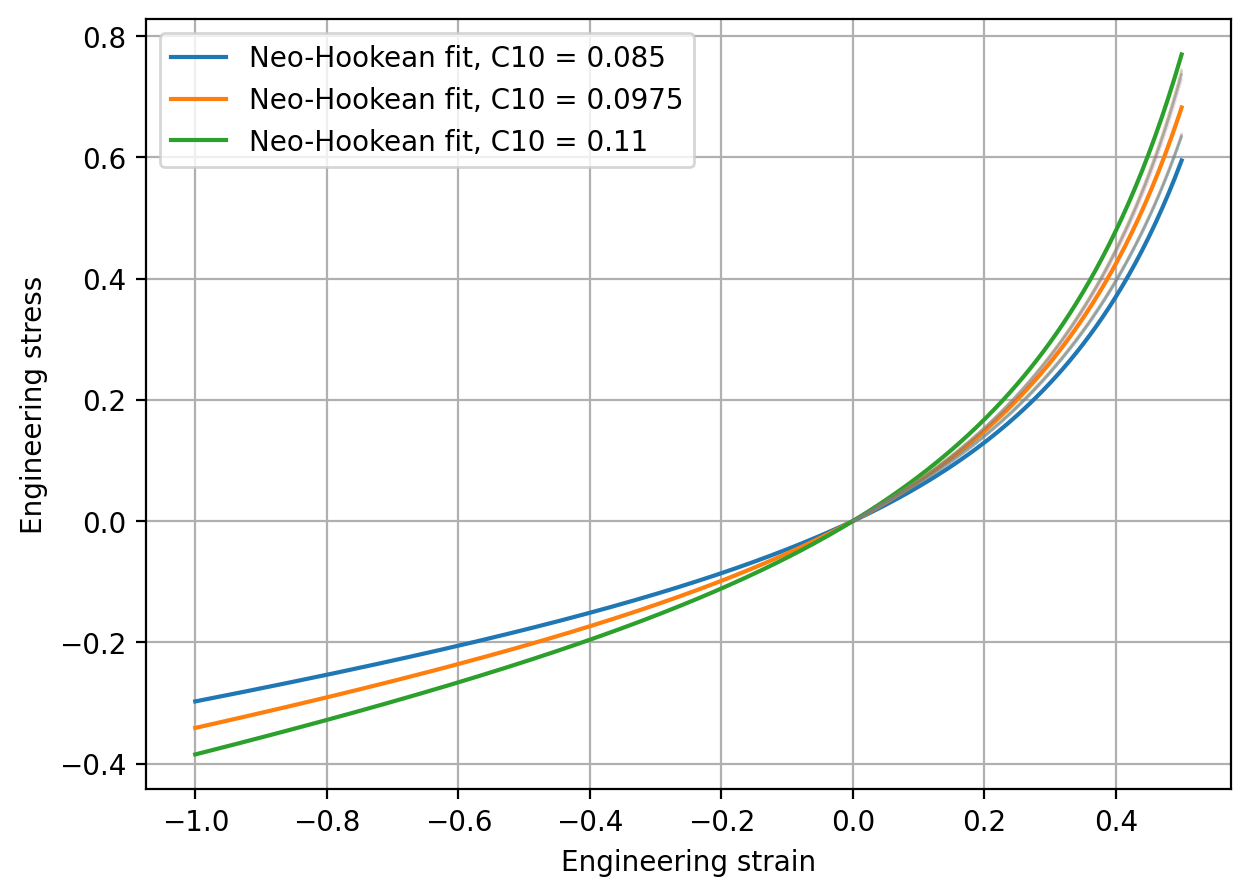

In [312]:
group_cols = ["orient", "sample", "repeat"]

df_fit = df.copy()

# Zero stress separately for each test curve
df_fit["stress_zeroed"] = (
    df_fit["stress"]
    - df_fit.groupby(group_cols)["stress"].transform("first")
)

# Optional: remove the very beginning if contact/preload effects dominate
#df_fit = df_fit[df_fit["strain"] > 0.005].copy()

# Compression stretch
df_fit["lambda"] = 1.0 - df_fit["strain"]

# Neo-Hookean compression predictor:
# stress = mu * (lambda^-2 - lambda)
df_fit["x"] = df_fit["lambda"]**(-2) - df_fit["lambda"]

# Keep only valid data
df_fit = df_fit.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["stress_zeroed", "x"]
)

# Least-squares fit for one global mu
x = df_fit["x"].to_numpy()
y = df_fit["stress_zeroed"].to_numpy()

mu = np.sum(x * y) / np.sum(x**2)
C10 = mu / 2

nu = 0.45 # poisson's ratio
K = 2 * mu * (1 + nu) / (3 * (1 - 2 * nu))
D1 = 2 / K

print(f" mu = {mu:.6g}")
print(f"C10 = {C10:.6g}")
#print(f"K   = {K:.6g}")
print(f"D1  = {D1:.6g}")

#PLOT#
fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=200)

strain_curve = np.linspace(-1, df_fit["strain"].max(), 300)
lambda_curve = 1.0 - strain_curve

for m in [0.17, 0.195, 0.22]:
    stress_curve = m * (lambda_curve**(-2) - lambda_curve)
    # Neo-Hookean curve
    ax.plot(strain_curve, stress_curve, linewidth=1.5, label=f"Neo-Hookean fit, C10 = {m/2:.4g}")

# Raw data
for name, g in df_fit.groupby(group_cols):
    ax.plot(g["strain"], g["stress_zeroed"], alpha=0.15, linewidth=0.8)

ax.set_xlabel("Engineering strain")
ax.set_ylabel("Engineering stress")
ax.legend()
ax.grid(True)
plt.show()

In [238]:
df_fit

,time,displacement,force,strain,stress,orient,sample,repeat,stress_zeroed,lambda,x
0,19.719999,0.0000,0.500000,0.000000,0.006366,Horizontal,1,1,0.000000,1.000000,0.000000
1,19.740000,0.0004,0.500000,0.000020,0.006366,Horizontal,1,1,0.000000,0.999980,0.000060
2,19.760000,0.0008,0.500000,0.000040,0.006366,Horizontal,1,1,0.000000,0.999960,0.000120
3,19.780001,0.0011,0.500000,0.000055,0.006366,Horizontal,1,1,0.000000,0.999945,0.000165
4,19.799999,0.0016,0.500000,0.000080,0.006366,Horizontal,1,1,0.000000,0.999920,0.000240
...,...,...,...,...,...,...,...,...,...,...,...
539959,614.780029,9.9985,50.200001,0.499925,0.639166,Vertical,3,3,0.632800,0.500075,3.498725
539960,614.799988,9.9988,50.200001,0.499940,0.639166,Vertical,3,3,0.632800,0.500060,3.498981
539961,614.820007,9.9992,50.299999,0.499960,0.640439,Vertical,3,3,0.634073,0.500040,3.499320
539962,614.840027,9.9995,50.299999,0.499975,0.640439,Vertical,3,3,0.634073,0.500025,3.499575


# Study 2
 - Try Ogden fit that fits compression data well but result in different tension behaviour 

#### OGDEN

Neo-Hookean mu  = 0.201812
Neo-Hookean C10 = 0.100906

Tension scale = 4.0
Initial shear modulus sum(mu_i) = 0.20218803
Ogden parameters:
  mu1 = 0.20218803, alpha1 = 3.201628,

Tension scale = 0.25
Initial shear modulus sum(mu_i) = 0.17852157
Ogden parameters:
  mu1 = 0.17852157, alpha1 = 0.27532734,


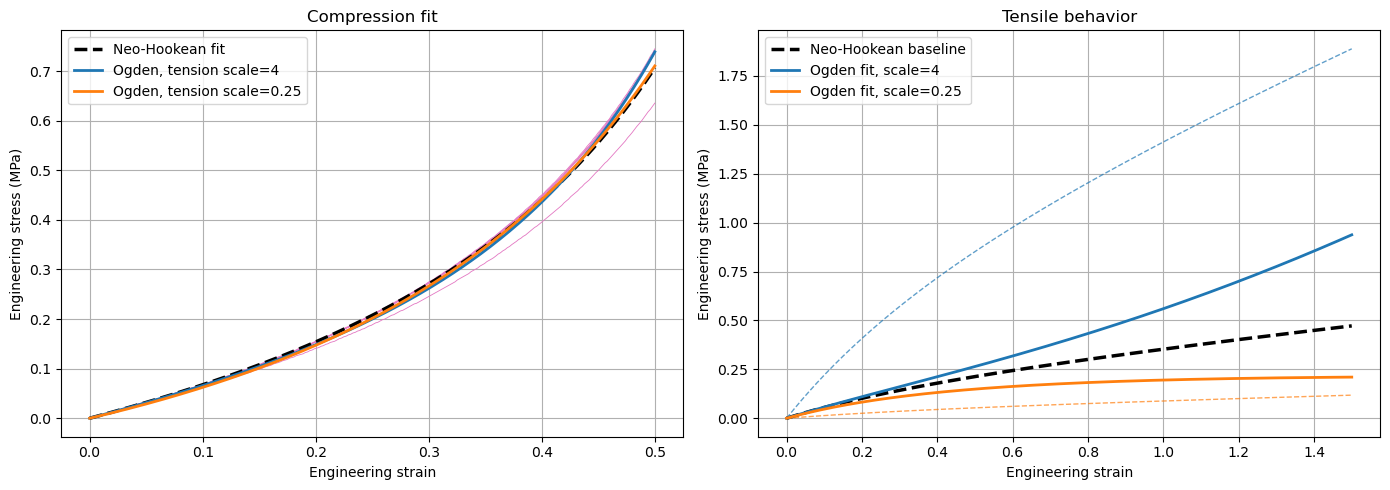

In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

# ============================================================
# USER SETTINGS
# ============================================================

group_cols = ["orient", "sample", "repeat"]

compression_strain_min = 0.00
compression_strain_max = 0.50
n_compression_points = 250

N_OGDEN = 1

tension_strain_max = 0.50
n_tension_points = 250
tension_scales = [4.0, 0.25]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = None # None for incompressible

# ============================================================
# PREPARE COMPRESSION DATA
# ============================================================

strain_grid = np.linspace(compression_strain_min, compression_strain_max, n_compression_points)
curves = []

for name, g in df.groupby(group_cols):
    g = g.sort_values("strain").copy()

    g["stress_zeroed"] = g["stress"] - g["stress"].iloc[0]

    if g["strain"].min() <= compression_strain_min and g["strain"].max() >= compression_strain_max:
        f = interp1d(g["strain"], g["stress_zeroed"], bounds_error=False, fill_value=np.nan)

        curves.append(pd.DataFrame({
            "strain": strain_grid,
            "stress": f(strain_grid),
            "orient": name[0],
            "sample": name[1],
            "repeat": name[2],
        }))

df_comp = pd.concat(curves, ignore_index=True).dropna(subset=["strain", "stress"])

# ============================================================
# NEO-HOOKEAN FIT FROM COMPRESSION
# ============================================================

eps_c = df_comp["strain"].to_numpy()
sig_c = df_comp["stress"].to_numpy()

lam_c = 1.0 - eps_c
x_c = lam_c ** -2.0 - lam_c

mu_NH = np.sum(x_c * sig_c) / np.sum(x_c ** 2)

print(f"Neo-Hookean mu  = {mu_NH:.6g}")
print(f"Neo-Hookean C10 = {mu_NH / 2.0:.6g}")

# ============================================================
# OGDEN FIT
# ============================================================

def ogden_P(lam, p):
    P = np.zeros_like(lam, dtype=float)
    for mu, alpha in zip(p[0::2], p[1::2]):
        P += (2.0 * mu / alpha) * (
            lam ** (alpha - 1.0)
            - lam ** (-alpha / 2.0 - 1.0)
        )
    return P

eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)
lam_t = 1.0 + eps_t

if N_OGDEN == 1:
    p0 = np.array([mu_NH, 2.0])
elif N_OGDEN == 2:
    p0 = np.array([0.70 * mu_NH, 2.0, 0.30 * mu_NH, -2.0])
elif N_OGDEN == 3:
    p0 = np.array([0.50 * mu_NH, 2.0, 0.30 * mu_NH, -2.0, 0.20 * mu_NH, 6.0])


lb = np.tile([-20.0 * abs(mu_NH), -20.0], N_OGDEN)
ub = np.tile([ 20.0 * abs(mu_NH),  20.0], N_OGDEN)

fit_results = []

for scale in tension_scales:
    sig_t = scale * mu_NH * (lam_t - lam_t ** -2.0)

    def resid(p):
        return np.r_[
            compression_weight * (-ogden_P(1.0 - eps_c, p) - sig_c),
            tension_weight * ( ogden_P(lam_t, p) - sig_t),
            1e-5 * p
        ]

    result = least_squares(resid, p0, bounds=(lb, ub), max_nfev=50000, xtol=1e-10, ftol=1e-10, gtol=1e-10)

    p = result.x
    mu_terms = p[0::2]
    alpha_terms = p[1::2]
    mu_initial = np.sum(mu_terms)

    if poisson_ratio == None:
        incompressible = True
        K = np.inf
        D_terms = [None] * N_OGDEN

    else:
        incompressible = False
        K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
            3.0 * (1.0 - 2.0 * poisson_ratio)
        )

        D_terms = np.zeros(N_OGDEN)
        D_terms[0] = 2.0 / K

    fit_results.append({
        "scale": scale,
        "params": p,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
    })

    print("\n" + "=" * 70)
    print(f"Tension scale = {scale}")
    print(f"Initial shear modulus sum(mu_i) = {mu_initial:.8g}")

    print("Ogden parameters:")
    for i in range(N_OGDEN):
        if incompressible:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g},"
            )
        else:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}, "
                f"D{i+1} = {D_terms[i]:.8g}"
            )

# ============================================================
# PLOTTING
# ============================================================

eps_c_plot = np.linspace(compression_strain_min, compression_strain_max, 300)
eps_t_plot = np.linspace(0.0, 1.5, 300)

neo_c_plot = mu_NH * ((1.0 - eps_c_plot) ** -2.0 - (1.0 - eps_c_plot))
neo_t_plot = mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Compression: experimental data
for _, g in df_comp.groupby(group_cols):
    ax[0].plot(g["strain"], g["stress"], linewidth=0.6, alpha=1, c='C6')

# Baselines
ax[0].plot(eps_c_plot,neo_c_plot,linestyle="--",linewidth=2.5,color="black",label="Neo-Hookean fit")
ax[1].plot(eps_t_plot,neo_t_plot,linestyle="--",linewidth=2.5,color="black",label="Neo-Hookean baseline")

# Ogden sensitivity curves
for i, res in enumerate(fit_results):
    scale = res["scale"]

    ax[0].plot(eps_c_plot,-ogden_P(1.0 - eps_c_plot, res["params"]),linewidth=2,label=f"Ogden, tension scale={scale:g}", c=f'C{i}')
    ax[1].plot(eps_t_plot,ogden_P(1.0 + eps_t_plot, res["params"]),linewidth=2,label=f"Ogden fit, scale={scale:g}", c=f'C{i}')

    ax[1].plot(
        eps_t_plot,
        scale * mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0),
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        c=f'C{i}'
    )

# Formatting
ax[0].set_title("Compression fit")
ax[1].set_title("Tensile behavior")

for ax_i in ax:
    ax_i.set_xlabel("Engineering strain")
    ax_i.set_ylabel("Engineering stress (MPa)")
    ax_i.grid(True)
    ax_i.legend()

fig.tight_layout()
plt.show()

In [ ]:
make script that takes in chosen neo-hookean c10 and set c10s to the ones used above that cover experimental data (or more justified ones)
then set tension data to something sensible and get fits that keep tension constant and vary compression 

If not then have to rely on current results and argue that because change in tension with constant compression didn't matter
then it was the compressive change in the two c10 runs that made the difference...


# Study 5
- improvement to study 2 script 
    - takes in provided Neo-Hookean param and uses that for either compression or tension then uses synthetic data for other

In [280]:
# ============================================================
# FUNCTIONS
# ============================================================

def neo_hookean_mu(C10):
    return 2.0 * C10


def neo_hookean_compression_stress(eps, mu):
    lam = 1.0 - eps
    return mu * (lam**-2.0 - lam)


def neo_hookean_tension_stress(eps, mu):
    lam = 1.0 + eps
    return mu * (lam - lam**-2.0)


def scaled_nh_compression_stress(eps, scale, mu):
    return scale * neo_hookean_compression_stress(eps, mu)


def scaled_nh_tension_stress(eps, scale, mu):
    return scale * neo_hookean_tension_stress(eps, mu)


def ogden_P(lam, p):
    P = np.zeros_like(lam, dtype=float)
    for mu, alpha in zip(p[0::2], p[1::2]):
        P += (2.0 * mu / alpha) * (
            lam**(alpha - 1.0)
            - lam**(-alpha / 2.0 - 1.0)
        )
    return P


def initial_guess(N, mu):
    guesses = {
        1: [mu, 2.0],
        2: [0.70 * mu, 2.0, 0.30 * mu, -2.0],
        3: [0.50 * mu, 2.0, 0.30 * mu, -2.0, 0.20 * mu, 6.0],
    }
    return np.array(guesses[N])


def compressibility_terms(mu_initial, N):
    if poisson_ratio is None:
        return True, np.inf, [None] * N

    K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
        3.0 * (1.0 - 2.0 * poisson_ratio)
    )

    D = np.zeros(N)
    D[0] = 2.0 / K

    return False, K, D






def compare_ogden_curves_on_non_synthetic_side(
    fit_results,
    synthetic_side,
    eps_c,
    lam_c,
    eps_t,
    lam_t,
    ogden_P,
):
    if len(fit_results) < 2:
        return

    if synthetic_side == "tension":
        side = "compression"
        eps_compare = eps_c
        lam_compare = lam_c
        curves = [-ogden_P(lam_compare, res["params"]) for res in fit_results]
    else:
        side = "tension"
        eps_compare = eps_t
        lam_compare = lam_t
        curves = [ogden_P(lam_compare, res["params"]) for res in fit_results]

    print("\n" + "=" * 70)
    print(f"Ogden curve comparison on non-synthetic side: {side}")

    for i in range(len(fit_results)):
        for j in range(i + 1, len(fit_results)):
            y_i = curves[i]
            y_j = curves[j]

            abs_diff = np.abs(y_i - y_j)
            idx = np.argmax(abs_diff)

            max_abs = abs_diff[idx]
            pct_at_max_abs = 100.0 * max_abs / abs(np.mean((y_i[idx], y_j[idx])))

            print("\n" + "-" * 70)
            print(
                f"Scale {fit_results[i]['scale']:g} vs "
                f"scale {fit_results[j]['scale']:g}"
            )
            print(f"Max absolute difference = {max_abs:.8g}")
            print(f"Percentage difference at max absolute difference = {pct_at_max_abs:.8g}%")
            print(f"  at {side} strain = {eps_compare[idx]:.8g}")
            print(f"  curve 1 stress = {y_i[idx]:.8g}")
            print(f"  curve 2 stress = {y_j[idx]:.8g}")

def compare_synthetic_compression_to_raw_orientation_data(
    fit_results,
    synthetic_side,
    synthetic_scales,
    df_raw,
    ogden_P,
    strain_col="strain",
    stress_col="stress_zeroed",
    orient_col="orient",
    horizontal_label="Horizontal",
    vertical_label="Vertical",
):
    if synthetic_side != "compression" or len(synthetic_scales) != 2:
        return

    high_scale = max(synthetic_scales)
    low_scale = min(synthetic_scales)

    cases = [
        (high_scale, horizontal_label),
        (low_scale, vertical_label),
    ]

    print("\n" + "=" * 70)
    print("Synthetic compression curve vs raw experimental data")

    for scale, orient in cases:
        res = next(r for r in fit_results if r["scale"] == scale)

        g = df_raw[df_raw[orient_col] == orient].copy()
        g = g.dropna(subset=[strain_col, stress_col])

        eps = g[strain_col].to_numpy()
        raw = g[stress_col].to_numpy()

        model = -ogden_P(1.0 - eps, res["params"])

        abs_diff = np.abs(model - raw)
        idx = np.argmax(abs_diff)

        max_abs = abs_diff[idx]
        pct_at_max_abs = 100.0 * max_abs / abs(np.mean((raw[idx], model[idx])))

        print("\n" + "-" * 70)
        print(f"Scale {scale:g} vs {orient} raw data")
        print(f"Max absolute difference = {max_abs:.8g}")
        print(f"Percentage difference at max absolute difference = {pct_at_max_abs:.8g}%")
        print(f"  at compression strain = {eps[idx]:.8g}")
        print(f"  Ogden stress = {model[idx]:.8g}")
        print(f"  raw stress = {raw[idx]:.8g}")
        print(f'sample', g['sample'].iloc[idx])
        print(f'repeat', g['repeat'].iloc[idx])



def ogden_simple_shear_stress(gamma, p):
    gamma = np.asarray(gamma, dtype=float)

    l1 = np.sqrt(1.0 + gamma**2 / 4.0) + gamma / 2.0
    l2 = np.sqrt(1.0 + gamma**2 / 4.0) - gamma / 2.0

    tau = np.zeros_like(gamma)

    for mu, alpha in zip(p[0::2], p[1::2]):
        tau += (2.0 * mu / alpha) * (l1**alpha - l2**alpha) / (l1 + l2)

    return tau

def plot_behaviour(
    fit_results,
    mu_NH,
    synthetic_side,
    compression_strain_min,
    compression_strain_max,
    tension_strain_max,
    ogden_P,
    scaled_nh_compression_stress,
    scaled_nh_tension_stress,
    neo_hookean_compression_stress,
    neo_hookean_tension_stress,
    df_raw=None,
    group_cols=None,
):
    eps_c_plot = np.linspace(compression_strain_min, compression_strain_max, 300)
    eps_t_plot = np.linspace(0.0, tension_strain_max, 300)
    gamma_plot = np.linspace(0.0, tension_strain_max, 300)

    lam_c_plot = 1.0 - eps_c_plot
    lam_t_plot = 1.0 + eps_t_plot

    nh_c_plot = neo_hookean_compression_stress(eps_c_plot, mu_NH)
    nh_t_plot = neo_hookean_tension_stress(eps_t_plot, mu_NH)
    nh_s_plot = mu_NH * gamma_plot

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    ax[0].plot(eps_c_plot, nh_c_plot, linestyle="--", linewidth=2.5, color="black", label="Neo-Hookean compression")
    ax[1].plot(eps_t_plot, nh_t_plot, linestyle="--", linewidth=2.5, color="black", label="Neo-Hookean tension")
    ax[2].plot(gamma_plot, nh_s_plot, linestyle="--", linewidth=2.5, color="black", label="Neo-Hookean shear")

    for i, res in enumerate(fit_results):
        scale = res["scale"]
        color = f"C{i}"

        ax[0].plot(
            eps_c_plot,
            -ogden_P(lam_c_plot, res["params"]),
            linewidth=2,
            color=color,
            label=f"Ogden, scale={scale:g}"
        )

        ax[1].plot(
            eps_t_plot,
            ogden_P(lam_t_plot, res["params"]),
            linewidth=2,
            color=color,
            label=f"Ogden, scale={scale:g}"
        )

        ax[2].plot(
            gamma_plot,
            ogden_simple_shear_stress(gamma_plot, res["params"]),
            linewidth=2,
            color=color,
            label=f"Ogden, scale={scale:g}"
        )

        if synthetic_side == "tension":
            ax[1].plot(
                eps_t_plot,
                scaled_nh_tension_stress(eps_t_plot, scale, mu_NH),
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                color=color
            )
        else:
            ax[0].plot(
                eps_c_plot,
                scaled_nh_compression_stress(eps_c_plot, scale, mu_NH),
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                color=color
            )

    if df_raw is not None and group_cols is not None:
        for _, g in df_raw.groupby(group_cols):
            ax[0].plot(g["strain"], g["stress_zeroed"], alpha=0.15, linewidth=0.8)

    ax[0].set_title("Compression behaviour")
    ax[1].set_title("Tensile behaviour")
    ax[2].set_title("Simple shear behaviour")

    ax[0].set_xlabel("Engineering compression strain")
    ax[1].set_xlabel("Engineering tensile strain")
    ax[2].set_xlabel("Shear strain, γ")

    for a in ax:
        a.set_ylabel("Stress")
        a.grid(True)
        a.legend()

    fig.tight_layout()
    plt.show()

Input Neo-Hookean C10 = 0.0975
Input Neo-Hookean mu  = 0.195
Synthetic side      = compression

scaled NH compression scale=1.11, NH tension
Initial shear modulus sum(mu_i) = 0.20209665
K = 1.953601
Ogden parameters:
  mu1 = 0.16166769, alpha1 = 2.1967943, D1 = 1.0237505
  mu2 = 0.040428966, alpha2 = -0.87682049, D2 = 0

scaled NH compression scale=0.89, NH tension
Initial shear modulus sum(mu_i) = 0.18781311
K = 1.8155268
Ogden parameters:
  mu1 = 0.23983785, alpha1 = 1.7921234, D1 = 1.1016087
  mu2 = -0.052024732, alpha2 = -0.61561984, D2 = 0

Ogden curve comparison on non-synthetic side: tension

----------------------------------------------------------------------
Scale 1.11 vs scale 0.89
Max absolute difference = 0.0037120212
Percentage difference at max absolute difference = 3.515258%
  at tension strain = 0.21686747
  curve 1 stress = 0.10745341
  curve 2 stress = 0.10374139

Synthetic compression curve vs raw experimental data

-------------------------------------------------

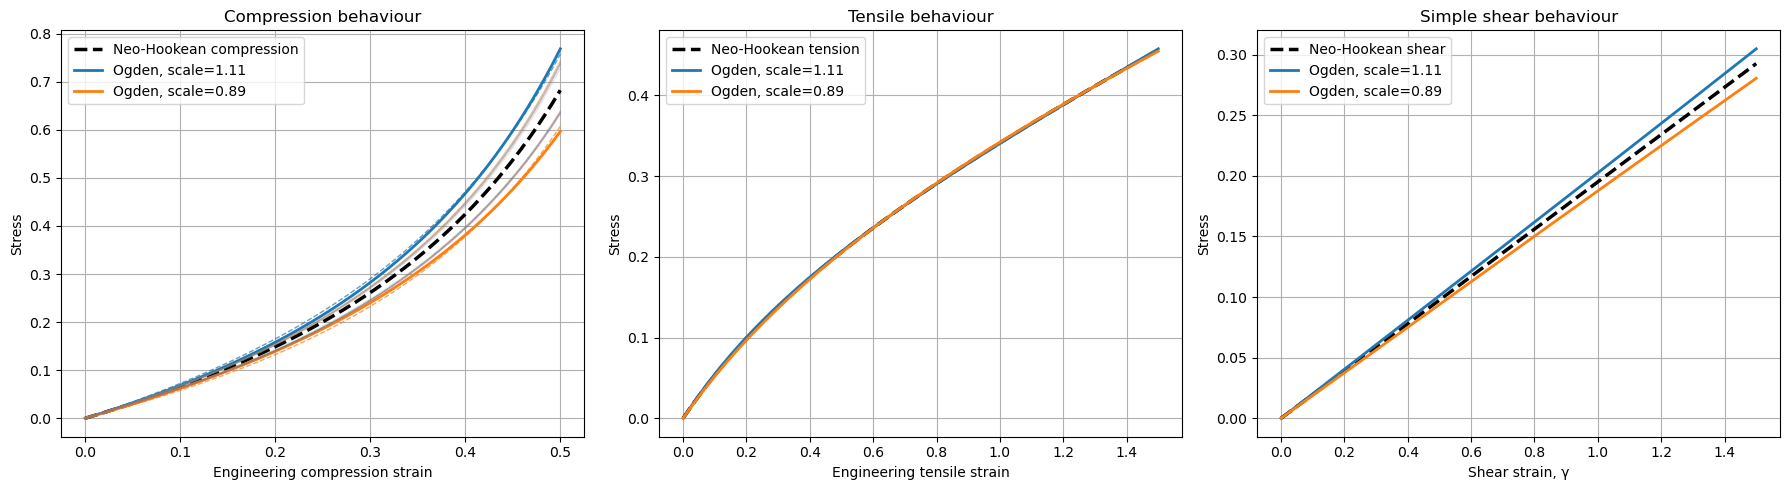

In [301]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# USER SETTINGS
# ============================================================

N_OGDEN = 2

compression_strain_min = 0.00
compression_strain_max = 0.50
n_compression_points = 250

tension_strain_max = 1.50
n_tension_points = 250

C10_input = 0.0975
synthetic_side = "compression"     # "compression" or "tension"
synthetic_scales = [1.11, 0.89]

compression_weight = 1.0
tension_weight = 5.0

poisson_ratio = 0.45                 # None for incompressible


# ============================================================
# TARGET DATA
# ============================================================

mu_NH = neo_hookean_mu(C10_input)

eps_c = np.linspace(compression_strain_min, compression_strain_max, n_compression_points)
eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)

lam_c = 1.0 - eps_c
lam_t = 1.0 + eps_t

print(f"Input Neo-Hookean C10 = {C10_input:.6g}")
print(f"Input Neo-Hookean mu  = {mu_NH:.6g}")
print(f"Synthetic side      = {synthetic_side}")

if synthetic_side == "tension":
    sig_c_base = neo_hookean_compression_stress(eps_c, mu_NH)
    sig_t_base = None
else:
    sig_c_base = None
    sig_t_base = neo_hookean_tension_stress(eps_t, mu_NH)


# ============================================================
# OGDEN FIT
# ============================================================

p0 = initial_guess(N_OGDEN, mu_NH)
lb = np.tile([-20.0 * abs(mu_NH), -20.0], N_OGDEN)
ub = np.tile([ 20.0 * abs(mu_NH),  20.0], N_OGDEN)

fit_results = []

for scale in synthetic_scales:
    if synthetic_side == "tension":
        sig_c = sig_c_base
        sig_t = scaled_nh_tension_stress(eps_t, scale, mu_NH)
        case_label = f"NH compression, scaled NH tension scale={scale:g}"

    else:
        sig_c = scaled_nh_compression_stress(eps_c, scale, mu_NH)
        sig_t = sig_t_base
        case_label = f"scaled NH compression scale={scale:g}, NH tension"

    def resid(p):
        return np.r_[
            compression_weight * (-ogden_P(lam_c, p) - sig_c),
            tension_weight * ( ogden_P(lam_t, p) - sig_t),
            1e-5 * p
        ]

    result = least_squares(
        resid,
        p0,
        bounds=(lb, ub),
        max_nfev=50000,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10
    )

    p = result.x
    mu_terms = p[0::2]
    alpha_terms = p[1::2]
    mu_initial = np.sum(mu_terms)

    incompressible, K, D_terms = compressibility_terms(mu_initial, N_OGDEN)

    fit_results.append({
        "scale": scale,
        "label": case_label,
        "params": p,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
        "sig_c": sig_c,
        "sig_t": sig_t,
    })

    print("\n" + "=" * 70)
    print(case_label)
    print(f"Initial shear modulus sum(mu_i) = {mu_initial:.8g}")

    if not incompressible:
        print(f"K = {K:.8g}")

    print("Ogden parameters:")

    for i in range(N_OGDEN):
        if incompressible:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}"
            )
        else:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}, "
                f"D{i+1} = {D_terms[i]:.8g}"
            )

compare_ogden_curves_on_non_synthetic_side(
    fit_results=fit_results,
    synthetic_side=synthetic_side,
    eps_c=eps_c,
    lam_c=lam_c,
    eps_t=eps_t,
    lam_t=lam_t,
    ogden_P=ogden_P,
)
compare_synthetic_compression_to_raw_orientation_data(
    fit_results=fit_results,
    synthetic_side=synthetic_side,
    synthetic_scales=synthetic_scales,
    df_raw=df_fit,
    ogden_P=ogden_P,
)

# ============================================================
# PLOTTING
# ============================================================

plot_behaviour(
    fit_results=fit_results,
    mu_NH=mu_NH,
    synthetic_side=synthetic_side,
    compression_strain_min=compression_strain_min,
    compression_strain_max=compression_strain_max,
    tension_strain_max=tension_strain_max,
    ogden_P=ogden_P,
    scaled_nh_compression_stress=scaled_nh_compression_stress,
    scaled_nh_tension_stress=scaled_nh_tension_stress,
    neo_hookean_compression_stress=neo_hookean_compression_stress,
    neo_hookean_tension_stress=neo_hookean_tension_stress,
    df_raw=df_fit,
    group_cols=group_cols,
)

Compression curves within 0.05 MPa of experimental curves  
and tension curves within 0.01 MPa of each other

## Alternate to study 2 using study 5 code

Input Neo-Hookean C10 = 0.0975
Input Neo-Hookean mu  = 0.195
Synthetic side      = tension

NH compression, scaled NH tension scale=1.5
Initial shear modulus sum(mu_i) = 0.21545439
K = 2.0827257
Ogden parameters:
  mu1 = 3.9, alpha1 = 1.4569275, D1 = 0.96028006
  mu2 = -3.6845456, alpha2 = 1.3395737, D2 = 0

NH compression, scaled NH tension scale=0.5
Initial shear modulus sum(mu_i) = 0.17473057
K = 1.6890622
Ogden parameters:
  mu1 = 3.1759428, alpha1 = -0.63512164, D1 = 1.184089
  mu2 = -3.0012123, alpha2 = -0.68039087, D2 = 0

Ogden curve comparison on non-synthetic side: compression

----------------------------------------------------------------------
Scale 1.5 vs scale 0.5
Max absolute difference = 0.0097378221
Percentage difference at max absolute difference = 8.8642609%
  at compression strain = 0.15662651
  curve 1 stress = 0.11472378
  curve 2 stress = 0.10498596


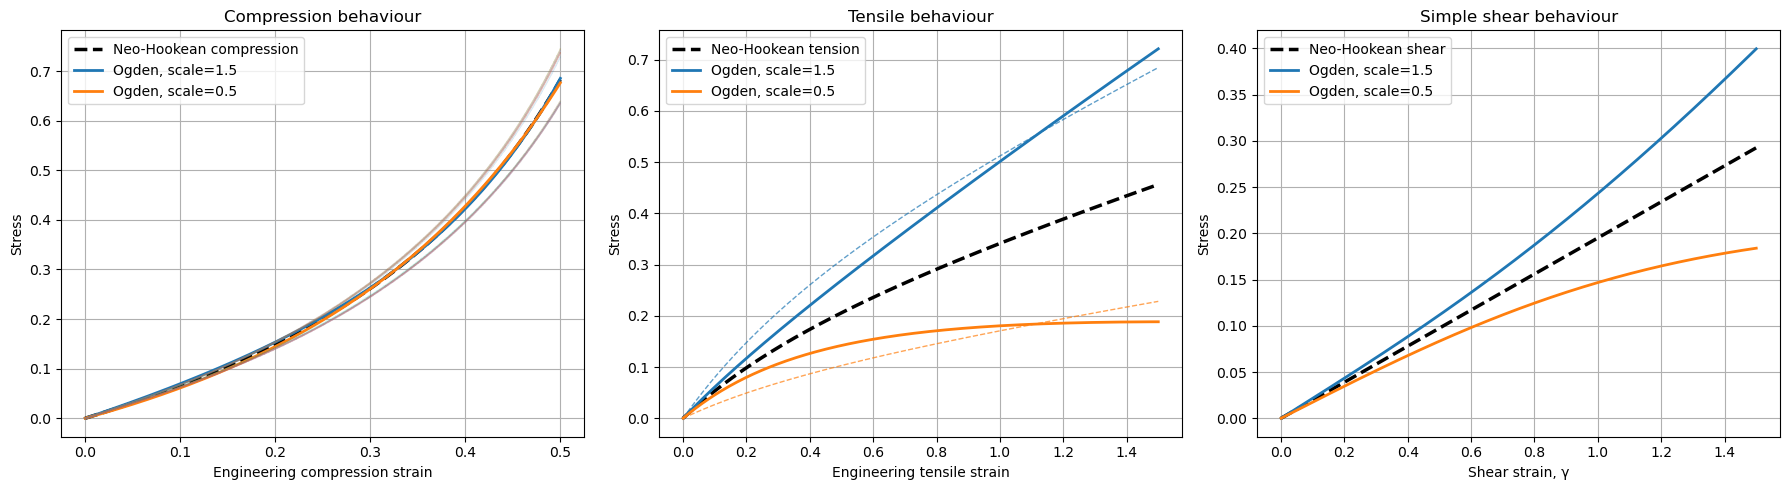

In [302]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ============================================================
# USER SETTINGS
# ============================================================

N_OGDEN = 2

compression_strain_min = 0.00
compression_strain_max = 0.50
n_compression_points = 250

tension_strain_max = 1.50
n_tension_points = 250

C10_input = 0.0975
synthetic_side = "tension"     # "compression" or "tension"
synthetic_scales = [1.5, 0.5]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = 0.45                 # None for incompressible

# ============================================================
# TARGET DATA
# ============================================================

mu_NH = neo_hookean_mu(C10_input)

eps_c = np.linspace(compression_strain_min, compression_strain_max, n_compression_points)
eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)

lam_c = 1.0 - eps_c
lam_t = 1.0 + eps_t

print(f"Input Neo-Hookean C10 = {C10_input:.6g}")
print(f"Input Neo-Hookean mu  = {mu_NH:.6g}")
print(f"Synthetic side      = {synthetic_side}")

if synthetic_side == "tension":
    sig_c_base = neo_hookean_compression_stress(eps_c, mu_NH)
    sig_t_base = None
else:
    sig_c_base = None
    sig_t_base = neo_hookean_tension_stress(eps_t, mu_NH)


# ============================================================
# OGDEN FIT
# ============================================================

p0 = initial_guess(N_OGDEN, mu_NH)
lb = np.tile([-20.0 * abs(mu_NH), -20.0], N_OGDEN)
ub = np.tile([ 20.0 * abs(mu_NH),  20.0], N_OGDEN)

fit_results = []

for scale in synthetic_scales:
    if synthetic_side == "tension":
        sig_c = sig_c_base
        sig_t = scaled_nh_tension_stress(eps_t, scale, mu_NH)
        case_label = f"NH compression, scaled NH tension scale={scale:g}"

    else:
        sig_c = scaled_nh_compression_stress(eps_c, scale, mu_NH)
        sig_t = sig_t_base
        case_label = f"scaled NH compression scale={scale:g}, NH tension"

    def resid(p):
        return np.r_[
            compression_weight * (-ogden_P(lam_c, p) - sig_c),
            tension_weight * ( ogden_P(lam_t, p) - sig_t),
            1e-5 * p
        ]

    result = least_squares(
        resid,
        p0,
        bounds=(lb, ub),
        max_nfev=50000,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10
    )

    p = result.x
    mu_terms = p[0::2]
    alpha_terms = p[1::2]
    mu_initial = np.sum(mu_terms)

    incompressible, K, D_terms = compressibility_terms(mu_initial, N_OGDEN)

    fit_results.append({
        "scale": scale,
        "label": case_label,
        "params": p,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
        "sig_c": sig_c,
        "sig_t": sig_t,
    })

    print("\n" + "=" * 70)
    print(case_label)
    print(f"Initial shear modulus sum(mu_i) = {mu_initial:.8g}")

    if not incompressible:
        print(f"K = {K:.8g}")

    print("Ogden parameters:")

    for i in range(N_OGDEN):
        if incompressible:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}"
            )
        else:
            print(
                f"  mu{i+1} = {mu_terms[i]:.8g}, "
                f"alpha{i+1} = {alpha_terms[i]:.8g}, "
                f"D{i+1} = {D_terms[i]:.8g}"
            )

compare_ogden_curves_on_non_synthetic_side(
    fit_results=fit_results,
    synthetic_side=synthetic_side,
    eps_c=eps_c,
    lam_c=lam_c,
    eps_t=eps_t,
    lam_t=lam_t,
    ogden_P=ogden_P,
)

# ============================================================
# PLOTTING
# ============================================================

plot_behaviour(
    fit_results=fit_results,
    mu_NH=mu_NH,
    synthetic_side=synthetic_side,
    compression_strain_min=compression_strain_min,
    compression_strain_max=compression_strain_max,
    tension_strain_max=tension_strain_max,
    ogden_P=ogden_P,
    scaled_nh_compression_stress=scaled_nh_compression_stress,
    scaled_nh_tension_stress=scaled_nh_tension_stress,
    neo_hookean_compression_stress=neo_hookean_compression_stress,
    neo_hookean_tension_stress=neo_hookean_tension_stress,
    df_raw=df_fit,
    group_cols=group_cols,
)

Compression curves within 0.01 MPa of each other  

# Polynomial fits

Input Neo-Hookean C10 = 0.15
Input Neo-Hookean mu  = 0.3

Tension scale = 4.0
Model = Reduced Polynomial, N = 3
Initial shear modulus = 0.30882019
Polynomial parameters:
  C10 = 0.15441009
  C20 = -0.0035632408
  C30 = 0.00091481835

Tension scale = 0.43
Model = Reduced Polynomial, N = 3
Initial shear modulus = 0.28895787
Polynomial parameters:
  C10 = 0.14447893
  C20 = 0.0050482007
  C30 = -0.0015067814


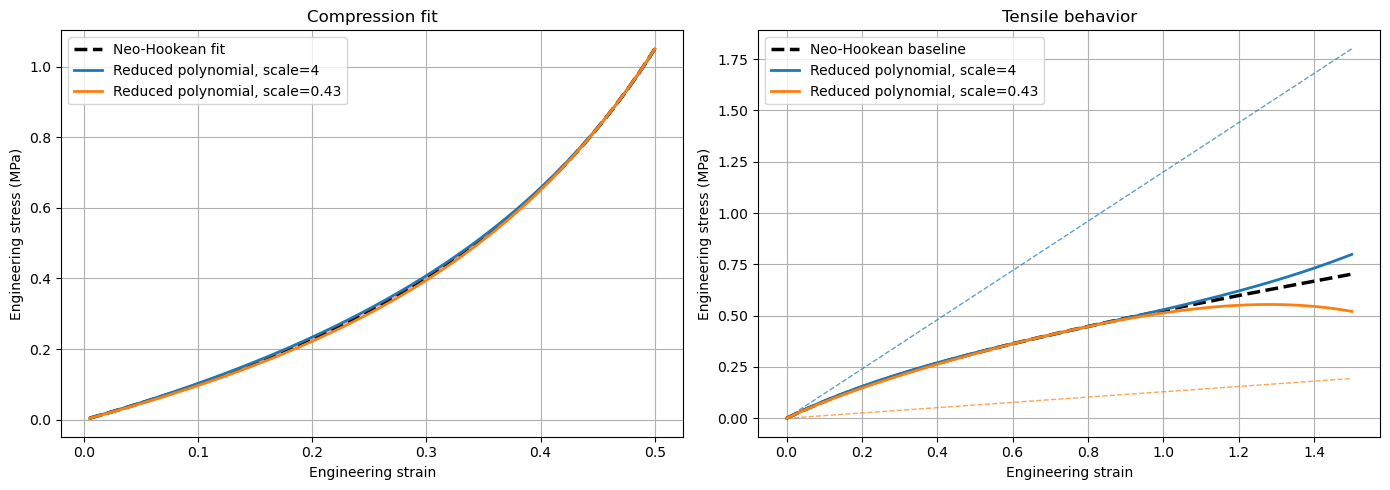

In [184]:
# ============================================================
# USER SETTINGS
# ============================================================

group_cols = ["orient", "sample", "repeat"]

compression_strain_min = 0.005
compression_strain_max = 0.50
n_compression_points = 250

poly_model = "reduced"       # "full" or "reduced"
N_POLY = 3

tension_strain_max = 0.50
n_tension_points = 250
tension_scales = [4.0, 0.43]

compression_weight = 5.0
tension_weight = 1.0

poisson_ratio = None      # None for incompressible

C10_input = 0.15          # supplied Neo-Hookean C10
mu_NH = 2.0 * C10_input

print(f"Input Neo-Hookean C10 = {C10_input:.6g}")
print(f"Input Neo-Hookean mu  = {mu_NH:.6g}")

# ============================================================
# SYNTHETIC COMPRESSION DATA FROM NEO-HOOKEAN MODEL
# ============================================================

eps_c = np.linspace(
    compression_strain_min,
    compression_strain_max,
    n_compression_points
)

lam_c = 1.0 - eps_c
sig_c = mu_NH * (lam_c ** -2.0 - lam_c)

df_comp = pd.DataFrame({
    "strain": eps_c,
    "stress": sig_c,
    "orient": "NeoHookean",
    "sample": 1,
    "repeat": 1,
})

# ============================================================
# POLYNOMIAL / REDUCED POLYNOMIAL FIT
# ============================================================

eps_t = np.linspace(0.0, tension_strain_max, n_tension_points)
lam_t = 1.0 + eps_t


def get_terms(model, N):
    if model == "reduced":
        return [(i, 0) for i in range(1, N + 1)]

    if model == "full":
        return [
            (i, j)
            for n in range(1, N + 1)
            for i in range(n, -1, -1)
            for j in [n - i]
        ]

    raise ValueError("poly_model must be 'full' or 'reduced'")


terms = get_terms(poly_model, N_POLY)


def invariants(lam):
    I1 = lam**2 + 2.0 * lam**-1
    I2 = 2.0 * lam + lam**-2
    return I1, I2


def poly_W(lam, C):
    I1, I2 = invariants(lam)
    W = np.zeros_like(lam, dtype=float)

    for c, (i, j) in zip(C, terms):
        W += c * (I1 - 3.0)**i * (I2 - 3.0)**j

    return W


def poly_P(lam, C):
    h = 1e-6
    return (poly_W(lam + h, C) - poly_W(lam - h, C)) / (2.0 * h)


def initial_mu(C):
    if poly_model == "reduced":
        C10 = C[0]
        C01 = 0.0
    else:
        C10 = C[terms.index((1, 0))] if (1, 0) in terms else 0.0
        C01 = C[terms.index((0, 1))] if (0, 1) in terms else 0.0

    return 2.0 * (C10 + C01)


def D_terms_from_mu(mu_initial):
    if poisson_ratio is None:
        return [None] * N_POLY, np.inf, True

    K = 2.0 * mu_initial * (1.0 + poisson_ratio) / (
        3.0 * (1.0 - 2.0 * poisson_ratio)
    )

    D_terms = np.zeros(N_POLY)
    D_terms[0] = 2.0 / K

    return D_terms, K, False


C0 = np.zeros(len(terms))

if (1, 0) in terms:
    C0[terms.index((1, 0))] = mu_NH / 2.0

if poly_model == "full" and (0, 1) in terms:
    C0[terms.index((0, 1))] = 0.0

fit_results = []

for scale in tension_scales:
    sig_t = scale * mu_NH * eps_t

    def resid(C):
        return np.r_[
            compression_weight * (-poly_P(1.0 - eps_c, C) - sig_c),
            tension_weight * ( poly_P(lam_t, C) - sig_t),
            1e-6 * C
        ]

    result = least_squares(
        resid,
        C0,
        max_nfev=50000,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10
    )

    C = result.x
    mu_initial = initial_mu(C)
    D_terms, K, incompressible = D_terms_from_mu(mu_initial)

    fit_results.append({
        "scale": scale,
        "params": C,
        "D_terms": D_terms,
        "K": K,
        "mu_initial": mu_initial,
    })

    print("\n" + "=" * 70)
    print(f"Tension scale = {scale}")
    print(f"Model = {poly_model.capitalize()} Polynomial, N = {N_POLY}")
    print(f"Initial shear modulus = {mu_initial:.8g}")

    if not incompressible:
        print(f"K = {K:.8g}")

    print("Polynomial parameters:")

    for c, (i, j) in zip(C, terms):
        print(f"  C{i}{j} = {c:.8g}")

    if not incompressible:
        print("D parameters:")
        for i, d in enumerate(D_terms, start=1):
            print(f"  D{i} = {d:.8g}")


# ============================================================
# PLOTTING
# ============================================================

eps_c_plot = np.linspace(compression_strain_min, compression_strain_max, 300)
eps_t_plot = np.linspace(0.0, 1.5, 300)

neo_c_plot = mu_NH * ((1.0 - eps_c_plot) ** -2.0 - (1.0 - eps_c_plot))
neo_t_plot = mu_NH * ((1.0 + eps_t_plot) - (1.0 + eps_t_plot) ** -2.0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for _, g in df_comp.groupby(group_cols):
    ax[0].plot(g["strain"], g["stress"], linewidth=0.6, alpha=1, c="C6")

ax[0].plot(
    eps_c_plot,
    neo_c_plot,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="Neo-Hookean fit"
)

ax[1].plot(
    eps_t_plot,
    neo_t_plot,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="Neo-Hookean baseline"
)

for i, res in enumerate(fit_results):
    scale = res["scale"]
    C = res["params"]

    ax[0].plot(
        eps_c_plot,
        -poly_P(1.0 - eps_c_plot, C),
        linewidth=2,
        label=f"{poly_model.capitalize()} polynomial, scale={scale:g}",
        c=f"C{i}"
    )

    ax[1].plot(
        eps_t_plot,
        poly_P(1.0 + eps_t_plot, C),
        linewidth=2,
        label=f"{poly_model.capitalize()} polynomial, scale={scale:g}",
        c=f"C{i}"
    )

    ax[1].plot(
        eps_t_plot,
        scale * mu_NH * eps_t_plot,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        c=f"C{i}"
    )

ax[0].set_title("Compression fit")
ax[1].set_title("Tensile behavior")

for ax_i in ax:
    ax_i.set_xlabel("Engineering strain")
    ax_i.set_ylabel("Engineering stress (MPa)")
    ax_i.grid(True)
    ax_i.legend()

fig.tight_layout()
plt.show()

# Check Abaqus model fits
- make sure i'm fitting material models the same way that abaqus is
---
### Results
- For $\nu$ < 0.5 , fits can be very different because Abaqus fit is based on chosen compressibility formulation
    - Abaqus, when fitting with compressibility specified, accounts for the volumetric part during the material fit.
- For $\nu$ = 0.5 , fits are much more similar but still a different
    - must still optimise slightly differently
- neo-hookean basically identical
---
### Thoughts
- For purposes of what I have done so far:
    - Neo-hookean is identical
    - ogden that is identical in compression/tension and varies around the neo-hookean is reasonable for sensitivity study
    - keeping identical ogden parameters and using D>0 is reasonable to check effect of compressibility.

In [ ]:
df_abaqus = df_fit[(df_fit['sample']==1)&(df_fit['repeat']==1)][['strain', 'stress_zeroed']].copy() * -1
df_abaqus.rename({'stress_zeroed':'stress'}, inplace=True, axis=1)
df_abaqus

,strain,stress
0,-0.000000,-0.00000
1,-0.000020,-0.00000
2,-0.000040,-0.00000
3,-0.000055,-0.00000
4,-0.000080,-0.00000
...,...,...
299974,-0.499920,-0.63662
299975,-0.499940,-0.63662
299976,-0.499955,-0.63662
299977,-0.499965,-0.63662


In [311]:
df_abaqus['stress'].to_csv('stress.csv', index=False)
df_abaqus['strain'].to_csv('strain.csv', index=False)

In [357]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# ----------------------------
# strain energy functions
# ----------------------------

def poly_terms(N, kind="full"):
    if kind == "reduced":
        return [(i, 0) for i in range(1, N + 1)]
    return [(i, n - i) for n in range(1, N + 1) for i in range(n, -1, -1)]


def W_poly(lams, C, terms):
    l1, l2, l3 = lams
    I1 = l1**2 + l2**2 + l3**2
    I2 = l1**2*l2**2 + l2**2*l3**2 + l3**2*l1**2
    return sum(c * (I1 - 3)**i * (I2 - 3)**j for c, (i, j) in zip(C, terms))


def W_ogden(lams, p):
    W = 0.0
    for mu, alpha in zip(p[0::2], p[1::2]):
        W += 2 * mu / alpha**2 * sum(lam**alpha - 1 for lam in lams)
    return W


def W_model(lams, fit):
    if "Ogden" in fit["model"]:
        return W_ogden(lams, fit["params"])
    return W_poly(lams, fit["params"], fit["terms"])


# ----------------------------
# deformation modes
# ----------------------------

def stretches(mode, x):
    x = np.asarray(x, dtype=float)
    lam = 1.0 + x

    if mode == "uniaxial":
        return np.array([lam, lam**-0.5, lam**-0.5])

    if mode == "biaxial":
        return np.array([lam, lam, lam**-2.0])

    if mode == "planar":
        return np.array([lam, np.ones_like(lam), lam**-1.0])

    if mode == "simple_shear":
        g = x
        l1 = np.sqrt(1.0 + g**2 / 4.0) + g / 2.0
        l2 = np.sqrt(1.0 + g**2 / 4.0) - g / 2.0
        return np.array([l1, l2, np.ones_like(g)])


def stress_mode(x, fit, mode, h=1e-6):
    x = np.asarray(x, dtype=float)

    def W_of_x(xv):
        return W_model(stretches(mode, xv), fit)

    return (W_of_x(x + h) - W_of_x(x - h)) / (2 * h)


# ----------------------------
# fitting functions
# ----------------------------

def make_D_terms(mu_initial, N, nu):
    if nu == 0.5:
        return np.zeros(N), np.inf

    K = 2.0 * mu_initial * (1.0 + nu) / (3.0 * (1.0 - 2.0 * nu))
    D = np.zeros(N)
    D[0] = 2.0 / K
    return D, K


def poly_initial_mu(C, terms):
    C10 = C[terms.index((1, 0))] if (1, 0) in terms else 0.0
    C01 = C[terms.index((0, 1))] if (0, 1) in terms else 0.0
    return 2.0 * (C10 + C01)


def fit_polynomial(df, N=2, kind="full", nu=0.5):
    terms = poly_terms(N, kind)
    x = df["strain"].to_numpy()
    y = df["stress"].to_numpy()

    C0 = np.zeros(len(terms))
    if (1, 0) in terms:
        C0[terms.index((1, 0))] = abs(y).max() / 2

    fit = {
        "model": f"{kind.capitalize()} polynomial N={N}",
        "terms": terms,
        "params": C0,
        "N": N,
        "nu": nu,
    }

    def resid(C):
        fit["params"] = C
        return stress_mode(x, fit, "uniaxial") - y

    fit["params"] = least_squares(resid, C0, max_nfev=50000).x
    fit["mu_initial"] = poly_initial_mu(fit["params"], terms)
    fit["D"], fit["K"] = make_D_terms(fit["mu_initial"], N, nu)

    return fit


def fit_reduced_polynomial(df, N=3, nu=0.5):
    return fit_polynomial(df, N=N, kind="reduced", nu=nu)


def fit_full_polynomial(df, N=2, nu=0.5):
    return fit_polynomial(df, N=N, kind="full", nu=nu)


def fit_ogden(df, N=2, nu=0.5):
    x = df["strain"].to_numpy()
    y = df["stress"].to_numpy()

    mu0 = np.sum(((1 + x)**-2 - (1 + x)) * (-y)) / np.sum(((1 + x)**-2 - (1 + x))**2)

    guesses = {
        1: [mu0, 2.0],
        2: [0.7 * mu0, 2.0, 0.3 * mu0, -2.0],
        3: [0.5 * mu0, 2.0, 0.3 * mu0, -2.0, 0.2 * mu0, 6.0],
    }

    p0 = np.array(guesses[N])
    lb = np.tile([-20 * abs(mu0), -20], N)
    ub = np.tile([ 20 * abs(mu0),  20], N)

    fit = {
        "model": f"Ogden N={N}",
        "params": p0,
        "N": N,
        "nu": nu,
    }

    def resid(p):
        fit["params"] = p
        return stress_mode(x, fit, "uniaxial") - y

    fit["params"] = least_squares(resid, p0, bounds=(lb, ub), max_nfev=50000).x
    fit["mu_initial"] = np.sum(fit["params"][0::2])
    fit["D"], fit["K"] = make_D_terms(fit["mu_initial"], N, nu)

    return fit


# ----------------------------
# coefficient printing
# ----------------------------

def print_fit(fit):
    print("\n" + "=" * 60)
    print(fit["model"], f"  (nu = {fit['nu']:.8g})")

    if "Ogden" in fit["model"]:
        for i, (mu, alpha) in enumerate(zip(fit["params"][0::2], fit["params"][1::2]), 1):
            print(f"\tmu{i} = {mu:.8g}, alpha{i} = {alpha:.8g}")
    else:
        for c, (i, j) in zip(fit["params"], fit["terms"]):
            print(f"\tC{i}{j} = {c:.8g}")

    #print(f"\tK = {fit['K']:.8g}")
    for i, d in enumerate(fit["D"], 1):
        print(f"\tD{i} = {d:.8g}")


# ----------------------------
# plotting
# ----------------------------

def plot_hyperelastic_fits(
    fits,
    uniaxial_range=(-0.5, 1.5),
    biaxial_range=(-0.3, 1.0),
    planar_range=(-0.5, 1.5),
    shear_range=(-0.5, 1.5),
    n=300,
    df=None,
):
    modes = [
        ("uniaxial", uniaxial_range, "Uniaxial", "Engineering strain"),
        ("biaxial", biaxial_range, "Biaxial", "Engineering strain"),
        ("planar", planar_range, "Planar (pure shear)", "Engineering strain"),
        ("simple_shear", shear_range, "Simple shear", "Shear strain γ"),
    ]

    fig, ax = plt.subplots(1, 4, figsize=(22, 5))

    for a, (mode, xrng, title, xlabel) in zip(ax, modes):
        x = np.linspace(*xrng, n)

        for fit in fits:
            a.plot(x, stress_mode(x, fit, mode), linewidth=2, label=fit["model"])

        if mode == "uniaxial" and df is not None:
            a.plot(df["strain"], df["stress"], "k.", alpha=0.15, markersize=2, label="data")

        a.set_title(title)
        a.set_xlabel(xlabel)
        a.set_ylabel("Nominal stress" if mode != "simple_shear" else "Shear stress")
        a.grid(True)
        a.legend()
        a.axhline(0, color='black', linewidth=0.8)
        a.axvline(0, color='black', linewidth=0.8)

    fig.tight_layout()
    plt.show()

### Compare compressible

In [ ]:
abaqus_fits_compressible = [
    {
        'model': 'Abaqus - Reduced polynomial N=1',
        'terms': [(1, 0)],
        'params': [0.09714351814],
        'N': 1,
        'nu': 0.45,
        'D': [1.06490148],
    },

    {
        'model': 'Abaqus - Ogden N=3',
        'params': [0.181238609, 2.37769990, 0.03334917028, 3.84011016, -0.01319816164, -1.86960080],
        'N': 3,
        'nu': 0.45,
        'D': [1.02734468, 0.0, 0.0],
    },

    {
        'model': 'Abaqus - Full polynomial N=2',
        'terms': [(1, 0), (0, 1), (2, 0), (1, 1), (0, 2)],
        'params': [0.100542797, -0.0006412223661, -0.09056591173, 0.104724531, -0.03106226437],
        'N': 2,
        'nu': 0.45,
        'D': [1.03550196, 0.0],
    }
]


Reduced polynomial N=1   (nu = 0.45)
	C10 = 0.096773581
	D1 = 1.0689723

Ogden N=3   (nu = 0.45)
	mu1 = 0.18697109, alpha1 = 2.3205835
	mu2 = -0.022569305, alpha2 = -0.15261942
	mu3 = 0.034866275, alpha3 = 2.4275717
	D1 = 1.0382826
	D2 = 0
	D3 = 0

Full polynomial N=2   (nu = 0.45)
	C10 = 0.16238859
	C01 = -0.059163823
	C20 = 0.089366334
	C11 = -0.073295641
	C02 = 0.019996391
	D1 = 1.0021652
	D2 = 0

Abaqus - Reduced polynomial N=1   (nu = 0.45)
	C10 = 0.097143518
	D1 = 1.0649015

Abaqus - Ogden N=3   (nu = 0.45)
	mu1 = 0.18123861, alpha1 = 2.3776999
	mu2 = 0.03334917, alpha2 = 3.8401102
	mu3 = -0.013198162, alpha3 = -1.8696008
	D1 = 1.0273447
	D2 = 0
	D3 = 0

Abaqus - Full polynomial N=2   (nu = 0.45)
	C10 = 0.1005428
	C01 = -0.00064122237
	C20 = -0.090565912
	C11 = 0.10472453
	C02 = -0.031062264
	D1 = 1.035502
	D2 = 0


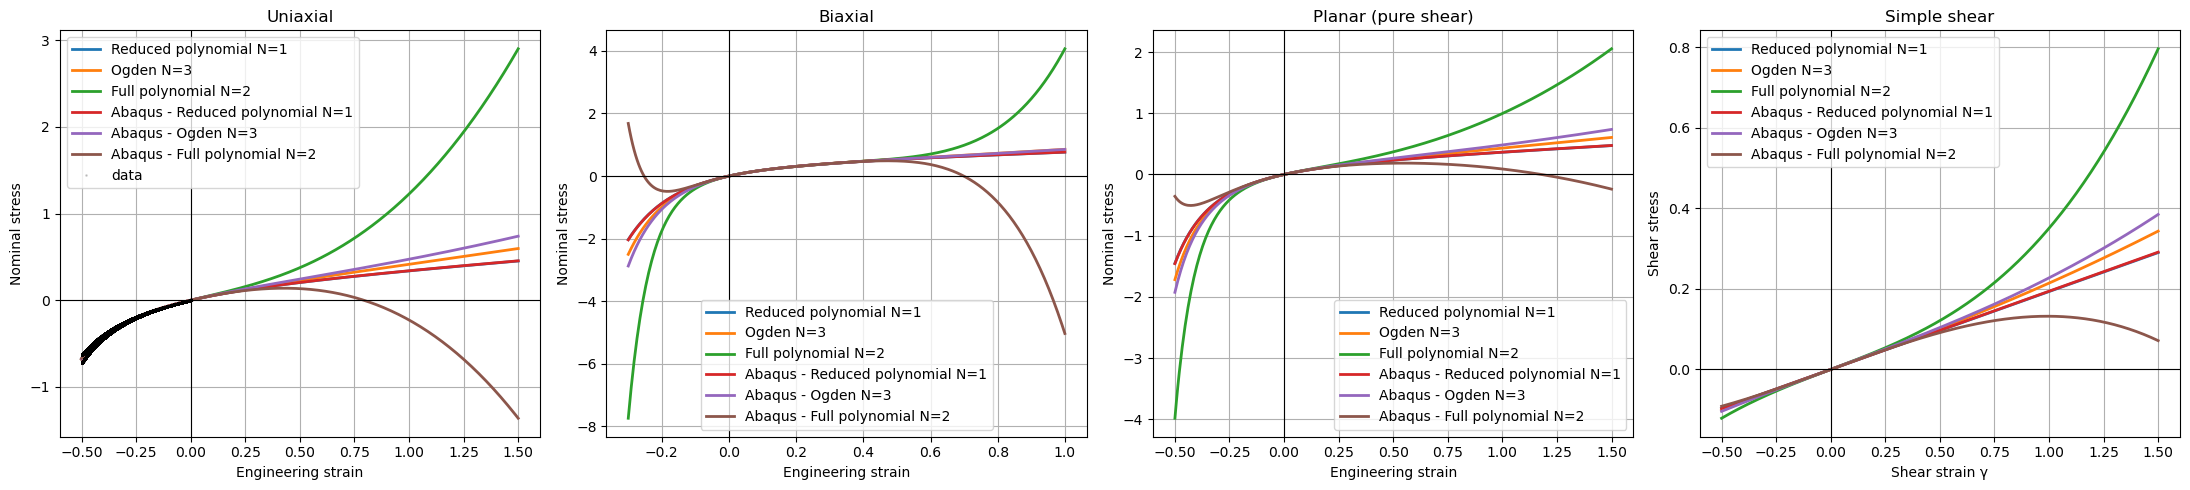

In [ ]:
fits = [
    fit_reduced_polynomial(df_abaqus, N=1, nu=0.45),
    fit_ogden(df_abaqus, N=3, nu=0.45),
    fit_full_polynomial(df_abaqus, N=2, nu=0.45),
]

for f in fits+abaqus_fits_compressible:
    print_fit(f)

plot_hyperelastic_fits(fits+abaqus_fits_compressible, df=df_abaqus)

### Compare incompressible

In [395]:
abaqus_fits_incompressible = [
    {
        'model': 'Abaqus - Reduced polynomial N=1',
        'terms': [(1, 0)],
        'params': [0.09714351814],
        'N': 1,
        'nu': 0.5,
        'D': [0.0],
    },

    {
        'model': 'Abaqus - Ogden N=2',
        'params': [0.212594911, 2.63231083, -0.01121569458, -1.88476409],
        'N': 2,
        'nu': 0.5,
        'D': [0.0, 0.0, 0.0],
    },

    {
        'model': 'Abaqus - Full polynomial N=1',
        'terms': [(1, 0), (0, 1)],
        'params': [0.102686026, -0.003975534528],
        'N': 1,
        'nu': 0.5,
        'D': [0.0, 0.0],
    }
]


Reduced polynomial N=1   (nu = 0.5)
	C10 = 0.096773581
	D1 = 0

Ogden N=2   (nu = 0.5)
	mu1 = 0.21142959, alpha1 = 2.4336319
	mu2 = -0.012073632, alpha2 = -0.94648235
	D1 = 0
	D2 = 0

Full polynomial N=1   (nu = 0.5)
	C10 = 0.095465251
	C01 = 0.00076265546
	D1 = 0

Abaqus - Reduced polynomial N=1   (nu = 0.5)
	C10 = 0.097143518
	D1 = 0

Abaqus - Ogden N=2   (nu = 0.5)
	mu1 = 0.21259491, alpha1 = 2.6323108
	mu2 = -0.011215695, alpha2 = -1.8847641
	D1 = 0
	D2 = 0
	D3 = 0

Abaqus - Full polynomial N=1   (nu = 0.5)
	C10 = 0.10268603
	C01 = -0.0039755345
	D1 = 0
	D2 = 0


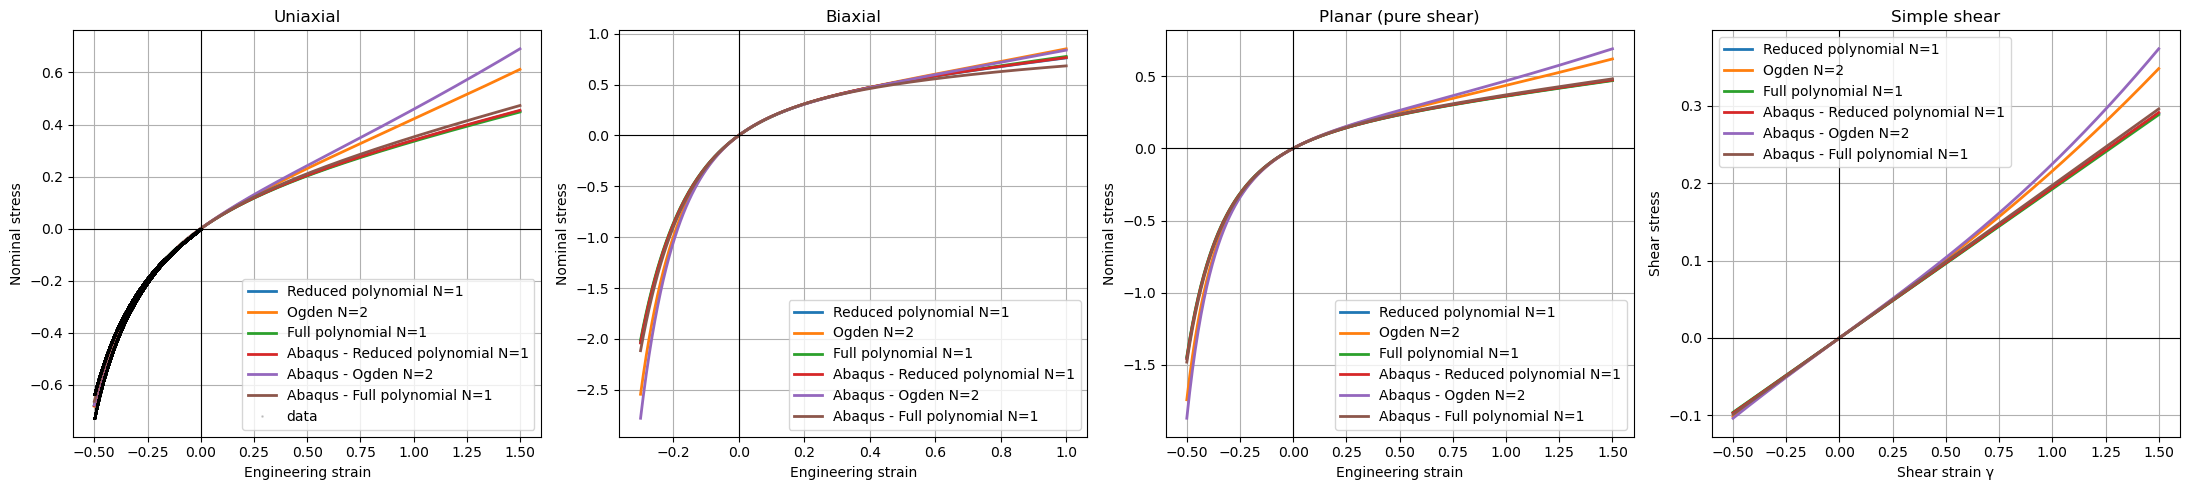

In [396]:
fits = [
    fit_reduced_polynomial(df_abaqus, N=1, nu=0.5),
    fit_ogden(df_abaqus, N=2, nu=0.5),
    fit_full_polynomial(df_abaqus, N=1, nu=0.5),
]

for f in fits+abaqus_fits_incompressible:
    print_fit(f)

plot_hyperelastic_fits(fits+abaqus_fits_incompressible, df=df_abaqus)

In [ ]:
Other models
- arruda-boyce 
- van der waals 
- marlow